### DECISION TREE

In [1]:
#The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results

In [49]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load the dataset into your preferred data analysis environment 
import pandas as pd
df = pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')


In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [10]:
df.duplicated().sum()

np.int64(1)

In [13]:
# Fill missing values of oldpeak column with mean value of the column
df['oldpeak'].fillna(df['oldpeak'].mean(), inplace=True)
df.isnull().sum()

C:\Users\Kaveeshvar\AppData\Local\Temp\ipykernel_29528\2397961779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].mean(), inplace=True)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

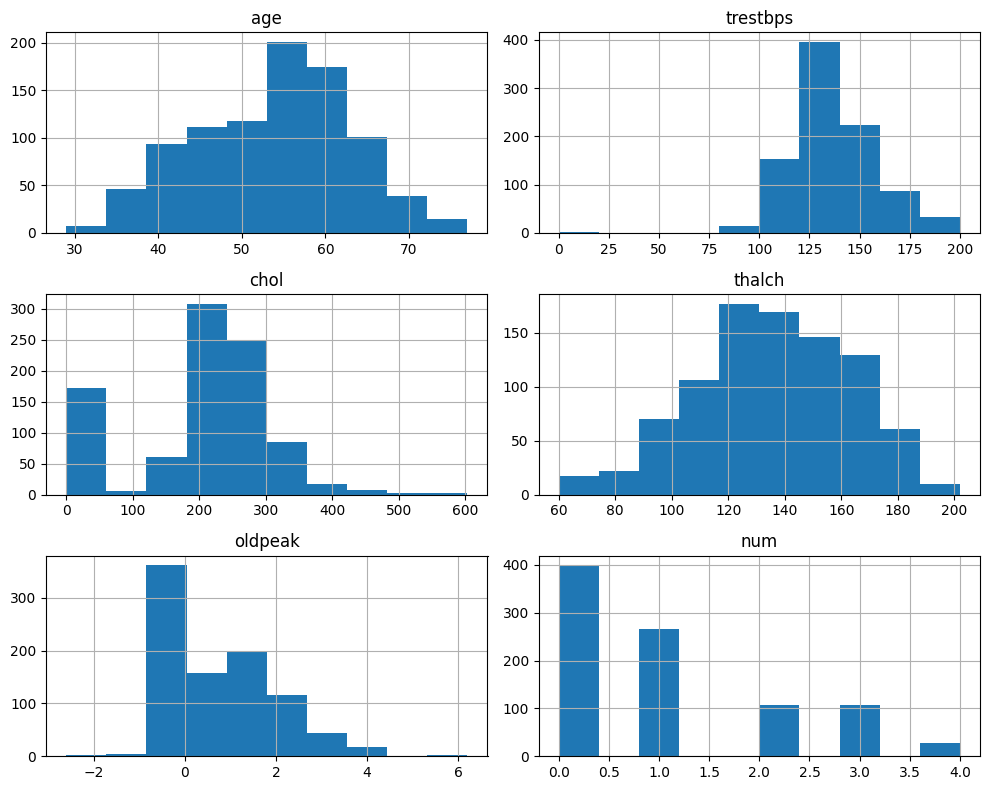

In [15]:
# Visualize the distribution of features, including histograms, box plots, and correlation matrices
# Columns in the dataset are :age	trestbps	chol	thalch	oldpeak	num
import matplotlib.pyplot as plt
import seaborn as sns
# Histograms
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

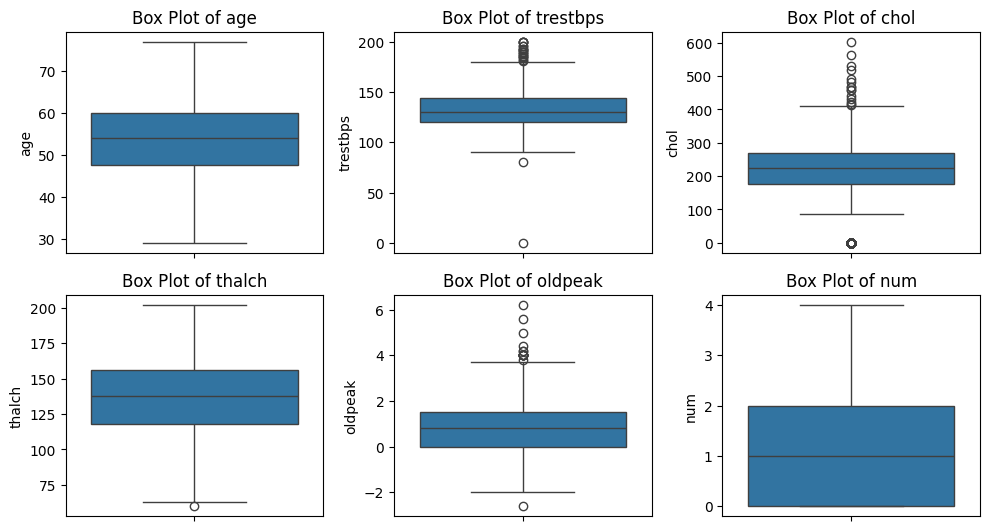

In [25]:
# box plots for numberic columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))

for i, column in enumerate(numeric_df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=numeric_df[column])
    plt.title(f'Box Plot of {column}')

plt.tight_layout()
plt.show()

In [26]:
# Outlier capping
for column in numeric_df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)
    

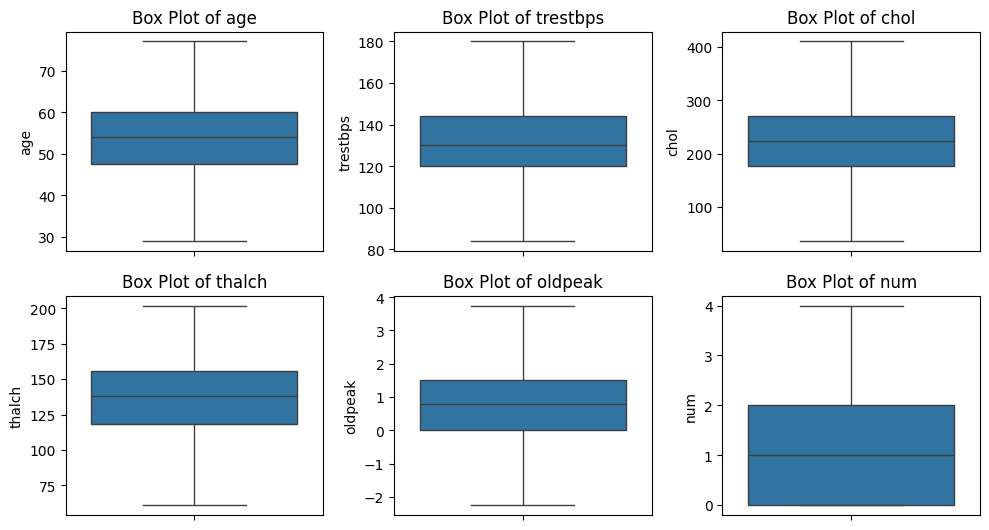

In [27]:
# box plots for numberic columns
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))

for i, column in enumerate(numeric_df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=numeric_df[column])
    plt.title(f'Box Plot of {column}')

plt.tight_layout()
plt.show()

In [31]:
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

In [33]:
df.select_dtypes(exclude='number')

,cp,fbs,restecg,exang,slope,thal
0,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,atypical angina,False,normal,False,flat,fixed defect
2,asymptomatic,False,normal,False,flat,fixed defect
3,typical angina,False,lv hypertrophy,False,flat,fixed defect
4,asymptomatic,False,normal,True,flat,fixed defect
...,...,...,...,...,...,...
903,asymptomatic,False,normal,False,upsloping,normal
904,asymptomatic,False,st-t abnormality,True,flat,reversable defect
905,non-anginal,False,lv hypertrophy,True,downsloping,reversable defect
906,non-anginal,True,st-t abnormality,TURE,downsloping,reversable defect


In [35]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(exclude='number').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233.0,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203.0,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192.0,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186.0,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201.0,0,1,126,3,1.5,1,0,0


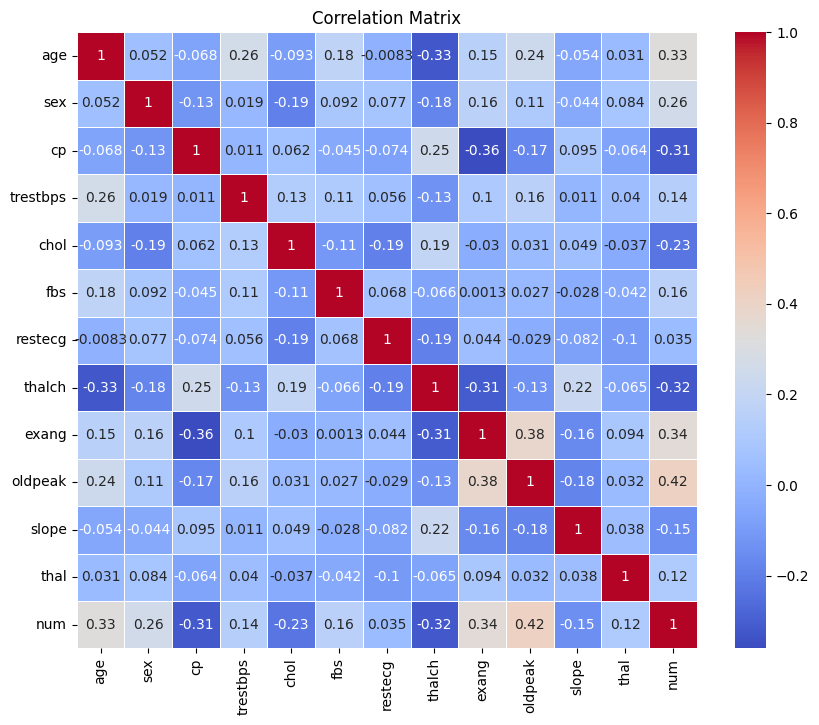

In [37]:
# correlation matrices
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [38]:
# Decision Tree Classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Define features and target variable
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
# Make predictions
y_pred = dt_classifier.predict(X_test)
# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[66 13  5  4  1]
 [10 27  4  5  1]
 [ 2  8  5  5  0]
 [ 7  3  2  5  0]
 [ 2  3  3  1  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        89
           1       0.50      0.57      0.53        47
           2       0.26      0.25      0.26        20
           3       0.25      0.29      0.27        17
           4       0.00      0.00      0.00         9

    accuracy                           0.57       182
   macro avg       0.35      0.37      0.36       182
weighted avg       0.55      0.57      0.56       182


Accuracy Score: 0.5659340659340659


In [45]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = dt_classifier.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.692652005374984


In [46]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [50]:
# Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
# Train the model with best hyperparameters
best_dt_classifier = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
best_dt_classifier.fit(X_train, y_train)
# Make predictions with the best model
y_pred_best = best_dt_classifier.predict(X_test)
# Evaluate the best model
print("Confusion Matrix for Best Model:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report for Best Model:")
print(classification_report(y_test, y_pred_best))
print("\nAccuracy Score for Best Model:", accuracy_score(y_test, y_pred_best))


Confusion Matrix for Best Model:
[[77 11  0  1  0]
 [15 27  0  5  0]
 [ 4 13  0  3  0]
 [ 6 10  0  1  0]
 [ 5  3  0  1  0]]

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        89
           1       0.42      0.57      0.49        47
           2       0.00      0.00      0.00        20
           3       0.09      0.06      0.07        17
           4       0.00      0.00      0.00         9

    accuracy                           0.58       182
   macro avg       0.25      0.30      0.27       182
weighted avg       0.47      0.58      0.52       182


Accuracy Score for Best Model: 0.5769230769230769


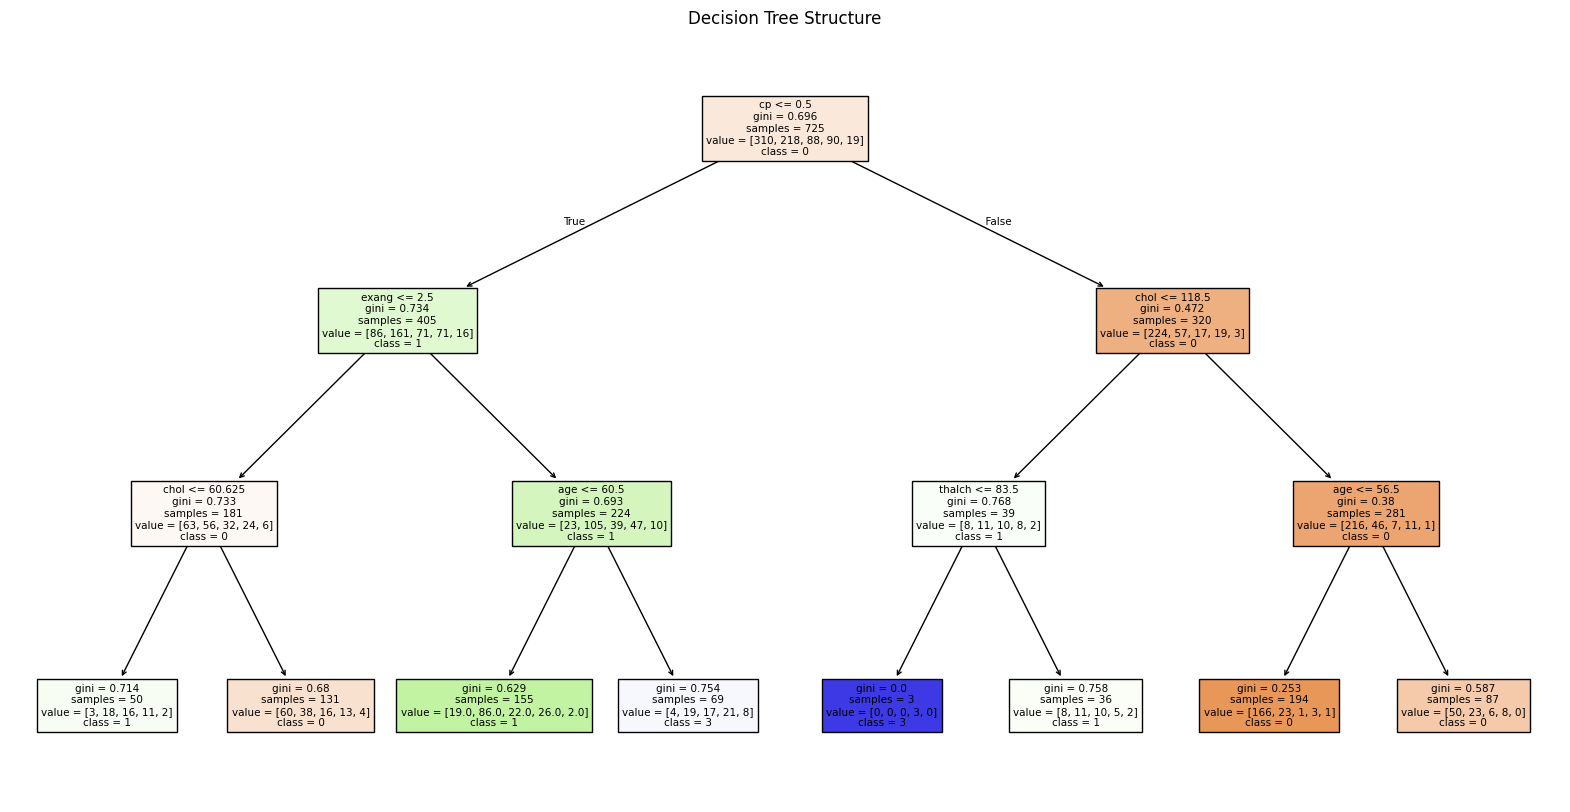

In [52]:
# Visualize the decision tree structure to understand the rules learned by the model and identify important features
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    best_dt_classifier,
    filled=True,
    feature_names=X.columns,
    class_names=['0','1','2','3','4']
)

plt.title('Decision Tree Structure')
plt.show()